# Data Load

In [2]:
import warnings
import pandas as pd

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*DtypeWarning.*")
    train = pd.read_csv("data/Training_BOP.csv", low_memory=False)
    test  = pd.read_csv("data/Testing_BOP.csv", low_memory=False)

print(train.shape, test.shape)
train.head()

(1687861, 23) (242076, 23)


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No


# Data Pre-Processing

In [3]:
train["went_on_backorder"].value_counts(dropna=False)
train = train.dropna(subset=["went_on_backorder"])
skus = train["sku"]

# create target and feature matrix; remove sku to not impact model
y = train["went_on_backorder"].map({"Yes": 1, "No": 0})
X = train.drop(columns=["went_on_backorder", "sku"])

# find yes/no columns
yn_cols = [c for c in X.columns
           if set(X[c].dropna().unique()).issubset({"Yes", "No"})]

X_proc = X.copy()

# convert yes/no columns to 1/0
for c in yn_cols:
    X_proc[c] = X_proc[c].map({"Yes": 1, "No": 0})


# train-test split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_proc, y, test_size=.2, random_state=42, stratify=y)

# impute nas with medians
num_cols = X_train.select_dtypes(include="number").columns
medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_val[num_cols] = X_val[num_cols].fillna(medians)

# Objective: Identify top 5% of highest-risk SKUs

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# baseline classifier
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="saga",
        max_iter=1000,
        class_weight="balanced",
        tol=1e-3,
        n_jobs=-1
    )
)
clf.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.001
,C,1.0


In [5]:
from sklearn.metrics import average_precision_score
import numpy as np

val_probs = clf.predict_proba(X_val)[:, 1]
print("Baseline Classifiers")
print("PR-AUC:", average_precision_score(y_val, val_probs))

K = int(0.05 * len(y_val))  # top 5%
topk = np.argsort(val_probs)[-K:]
print("Precision@K:", y_val.iloc[topk].mean())
print("Recall@K:", y_val.iloc[topk].sum() / y_val.sum())

Baseline Classifiers
PR-AUC: 0.014558680506119949
Precision@K: 0.025777777777777778
Recall@K: 0.03851261620185923


In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score
import numpy as np

# upgrade from base model to hgb classifier
hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)
hgb.fit(X_train, y_train)

val_probs = hgb.predict_proba(X_val)[:, 1]
print("HGB PR-AUC:", average_precision_score(y_val, val_probs))

HGB PR-AUC: 0.22772181016232176


In [10]:
def prec_recall_at_frac(y_true, scores, frac):
    K = int(frac * len(y_true))
    idx = np.argsort(scores)[-K:]
    precision = y_true.iloc[idx].mean()
    recall = y_true.iloc[idx].sum() / y_true.sum()
    return K, precision, recall

fracs = [0.005, 0.01, 0.02, 0.05]

rows = []
for frac in fracs:
    K, p, r = prec_recall_at_frac(y_val, val_probs, frac)
    rows.append({
        "top_frac": frac,
        "top_pct": frac * 100,
        "K": K,
        "precision_at_k": p,
        "recall_at_k": r
    })

topk_table = pd.DataFrame(rows).sort_values("top_frac").reset_index(drop=True)
topk_table.to_csv("topk_table.csv", index=False)
topk_table

,top_frac,top_pct,K,precision_at_k,recall_at_k
0,0.005,0.5,1687,0.335507,0.250553
1,0.010,1.0,3375,0.258074,0.385569
2,0.020,2.0,6751,0.180714,0.540062
3,0.050,5.0,16878,0.099656,0.744577


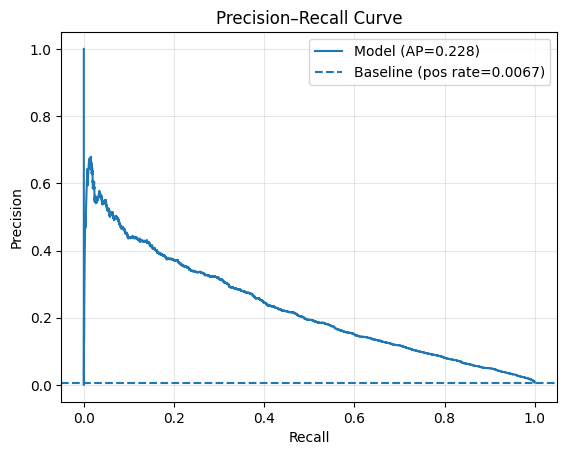

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
ap = average_precision_score(y_val, val_probs)

# Baseline precision = positive rate
baseline = y_val.mean()

plt.figure()
plt.plot(recall, precision, label=f"Model (AP={ap:.3f})")
plt.axhline(baseline, linestyle="--", label=f"Baseline (pos rate={baseline:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("pr_curve.png", dpi=200, bbox_inches='tight')
plt.show()

In [23]:
# testing on holdout set
# perform pre-processing similar to above
X_test = test.drop(columns=["sku", "went_on_backorder"], errors = "ignore").copy()

for c in yn_cols:
    if c in X_test.columns:
        X_test[c] = X_test[c].map({"Yes": 1, "No": 0})

full_medians = X_proc[num_cols].median()
X_full = X_proc.copy()
X_full[num_cols] = X_full[num_cols].fillna(full_medians)
X_test[num_cols] = X_test[num_cols].fillna(full_medians)

In [20]:
# fit data and compute probability of going on BO
hgb.fit(X_full, y)
X_test = X_test.reindex(columns=X_full.columns, fill_value=0)
test_probs = hgb.predict_proba(X_test)[:, 1]

In [25]:
submission = pd.DataFrame({
    "sku": test["sku"],
    "went_on_backorder": test_probs
})
submission.to_csv("submission.csv", index=False)

In [18]:
import json

results = {
    "pr_auc": float(ap),
    "top1pct_precision": float(topk_table.loc[topk_table["top_pct"] == 1.0, "precision_at_k"].iloc[0]),
    "top1pct_recall": float(topk_table.loc[topk_table["top_pct"] == 1.0, "recall_at_k"].iloc[0]),
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

# Feature Importance

In [27]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(hgb, X_val, y_val, n_repeats=3, random_state=42, n_jobs=-1)
imp = (pd.Series(perm.importances_mean, index=X_val.columns)
       .sort_values(ascending=False)).head(15)

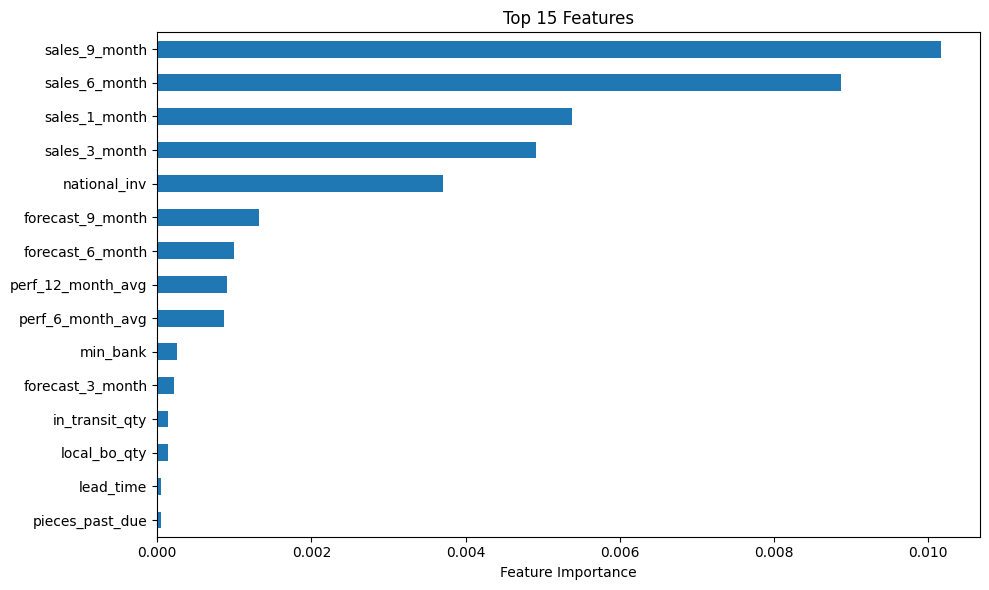

In [29]:
plt.figure(figsize=(10,6))
imp.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Top 15 Features")
plt.tight_layout()
plt.savefig("top15_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

# Final Results

Model: HistGradientBoostingClassifier

PR-AUC: 0.228 (as compared to baseline of .0067)

Top-5% (K=16878): Precision@K = 0.100, Recall@K = 0.745

Interpretation: reviewing the top-risk 5% of SKUs captures ~75% of backorders at ~10% precision.